In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from sklearn.model_selection import StratifiedShuffleSplit
from utils import load_file

In [11]:
data_path = './data'

## Data preparation

Firstly, we will prepare the dataset by cropping small patches of 32X32 around each field as the original images are huge and most of its area are not included in training nor test data.

In [3]:
# List of dates that an observation from Sentinel-2 is provided in the training dataset
dates = [datetime.datetime(2019, 6, 6, 8, 10, 7),
         datetime.datetime(2019, 7, 1, 8, 10, 4),
         datetime.datetime(2019, 7, 6, 8, 10, 8),
         datetime.datetime(2019, 7, 11, 8, 10, 4),
         datetime.datetime(2019, 7, 21, 8, 10, 4),
         datetime.datetime(2019, 8, 5, 8, 10, 7),
         datetime.datetime(2019, 8, 15, 8, 10, 6),
         datetime.datetime(2019, 8, 25, 8, 10, 4),
         datetime.datetime(2019, 9, 9, 8, 9, 58),
         datetime.datetime(2019, 9, 19, 8, 9, 59),
         datetime.datetime(2019, 9, 24, 8, 9, 59),
         datetime.datetime(2019, 10, 4, 8, 10),
         datetime.datetime(2019, 11, 3, 8, 10)]

# List of bands names included in the dataset
bands = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'CLD']

Reading the data

In [17]:
tile_no = 2
bands_arr = np.zeros((tile_no,13,13,3035,2016), dtype = np.float32) # 4 tiles X 13 days X 13 bands X 3035 pixels X 2016 pixels
#read all images
for tile in range(tile_no):
    for idx, d in enumerate(dates): # 2) For each date
        d = ''.join(str(d.date()).split('-')) # Nice date string
        # t = str(tile)
        t = str(tile+1) # tile starts from 1
        for ibx, b in enumerate(bands): # 3) For each band
            im = load_file(f"{data_path}/{t}/{d}/{t}_{b}_{d}.tif").astype(np.float32)
            # Load im
            #im = load_file(f"{data_path}/{t}/{d}/{t[1]}_{b}_{d}.tif").astype(np.float32)
            # im = load_file(f"{data_path}/ref_african_crops_kenya_02_source/ref_african_crops_kenya_02_tile_{t}_{d}/{b}.tif").astype(np.float32)
            bands_arr[tile,idx,ibx] = im

In [21]:
print(f"{data_path}/{t}/{1}_field_ids.tif")

./data/2/1_field_ids.tif


In [40]:
def create_dataset(bands_arr, radius):
    """
    This a function that go through each field in the data and crop a (2*radius)X(2*radius) patch.
    """
    # imgs = np.zeros((4688,13,13,radius*2,radius*2), dtype = np.float32) # patches matrix of dataset_size X 13 days X 13 bands X (2*radius)X(2*radius)
    # areas = np.zeros((4688,), dtype = np.int) # it has the area of each field in the dataset
    # gts = np.zeros((4688,), dtype = np.int) # it has the ground truth of each field in the dataset
    # field_masks = np.zeros((4688,1,radius*2,radius*2), dtype = np.float32) # fields matrix that has ones for the pixel belongs to the field, zeros otherwith of dataset_size X (2*radius)X(2*radius)

    imgs = np.zeros((1013,13,13,radius*2,radius*2), dtype = np.float32) # patches matrix of dataset_size X 13 days X 13 bands X (2*radius)X(2*radius)
    areas = np.zeros((1013,), dtype = np.int64) # it has the area of each field in the dataset
    gts = np.zeros((1013,), dtype = np.int64) # it has the ground truth of each field in the dataset
    field_masks = np.zeros((1013,1,radius*2,radius*2), dtype = np.float32) # fields matrix that has ones for the pixel belongs to the field, zeros otherwith of dataset_size X (2*radius)X(2*radius)
    fields_arr = []
    ifx = 0
    
    for tile in range(2):
        #load field id and label matrices of the tile
        fids = f"{data_path}/{tile+1}/{tile+1}_field_id.tif"
        labs = f"{data_path}/{tile+1}/{tile+1}_label.tif"
        # fids = f'{data_path}/ref_african_crops_kenya_02_labels/ref_african_crops_kenya_02_tile_0{tile}_label/field_ids.tif'
        # labs = f'{data_path}/ref_african_crops_kenya_02_labels/ref_african_crops_kenya_02_tile_0{tile}_label/labels.tif'
        field_id = load_file(fids)
        labels = load_file(labs)
        
        for field in np.unique(field_id):
            if field == 0: # if a pixel has 0 as an ID, it means it is not included neither in training nor test data.
              continue
            fields_arr.append(field)
            
            #find pixels belong to current field id
            area_mask = field_id == field
            
            #extract ground-truth class
            area_gt = np.unique(labels[area_mask])[0] 
            
            #calculate the median pixel position to crop around it
            idxx = np.where(area_mask)
            momentx = np.median(idxx[0]).astype(np.int64)
            momenty = np.median(idxx[1]).astype(np.int64)
            
            #create crop
            patch = bands_arr[tile,:,:,max(0, momentx-radius): momentx+radius, max(0, momenty-radius): momenty+radius]
            
            #pad crops in tiles borders with zeros
            imgs[ifx, :, :, :patch.shape[-2], :patch.shape[-1]] = patch
            
            #create crop's field mask (1s for pixels belong to current field id and zeros otherwise)
            field_patch = area_mask[max(0, momentx-radius): momentx+radius, max(0, momenty-radius): momenty+radius]
            
            #pad crop's field mask in tiles borders with zeros
            field_masks[ifx, 0, :patch.shape[-2], :patch.shape[-1]] = field_patch
            
            #make sure the crop's field mask is not empty
            if field_patch.sum() == 0:
                print(ifx, momentx-radius, momentx+radius, momenty-radius, momenty+radius)
            
            #calculate field area
            areas[ifx] = area_mask.sum()
            gts[ifx] = area_gt - 1
            ifx += 1
    
    return imgs, areas, gts, field_masks, fields_arr

In [41]:
#create crops of 32X32 around each field id center
imgs, areas, gts, field_masks, fields_arr = create_dataset(bands_arr, 16)

## Data Exploration

In [45]:
plt.rcParams["figure.figsize"] = (15,10)

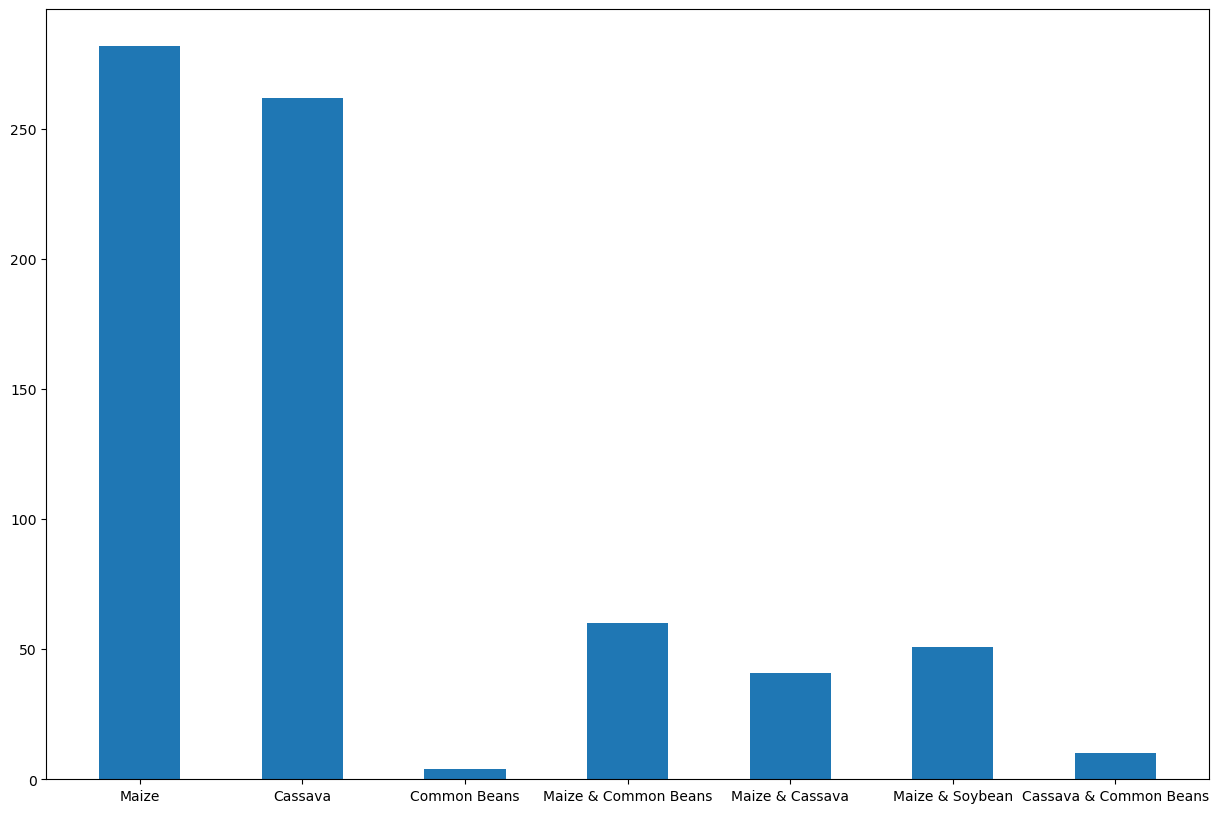

In [46]:
_, counts = np.unique(gts[gts > -1], return_counts=True)
labels = ['Maize', 'Cassava', 'Common Beans', 'Maize & Common Beans', 'Maize & Cassava', 'Maize & Soybean', 'Cassava & Common Beans']
plt.bar(labels, counts, align='center', width = 0.5)
plt.gca().set_xticks(labels)
plt.show()

Text(0, 0.5, 'No. samples')

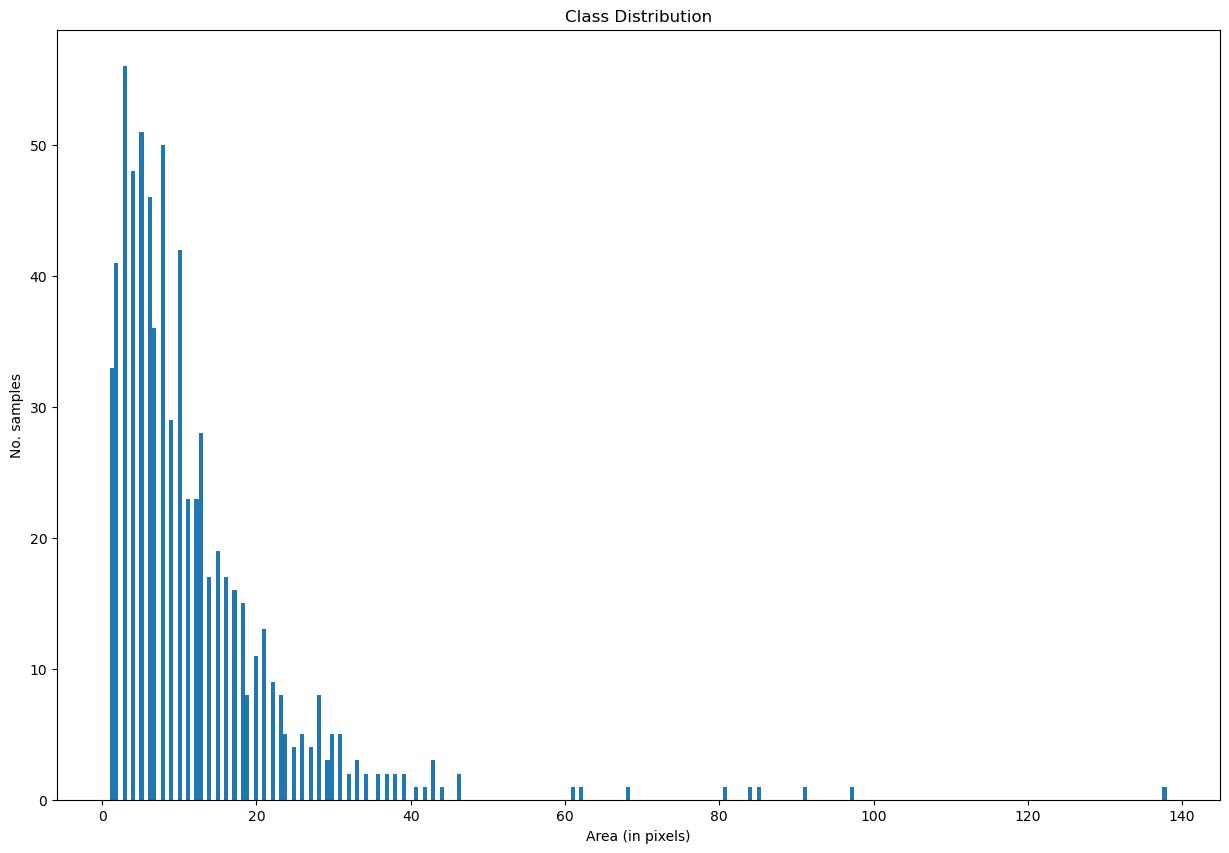

In [47]:
plt.rcParams["figure.figsize"] = (15,10)
plt.hist(areas[gts > -1], bins=250)
plt.title('Class Distribution')
plt.xlabel('Area (in pixels)')
plt.ylabel('No. samples')

In [48]:
band_skewness = []
band_skewness_after_sqrt = []
for c in range(13):
    #calculate skewness
    band_skewness.append(pd.Series(imgs[:,:,c].flatten()).skew())
    #calculate skewness after applying sqrt
    band_skewness_after_sqrt.append(pd.Series(np.sqrt(imgs[:,:,c].flatten())).skew())

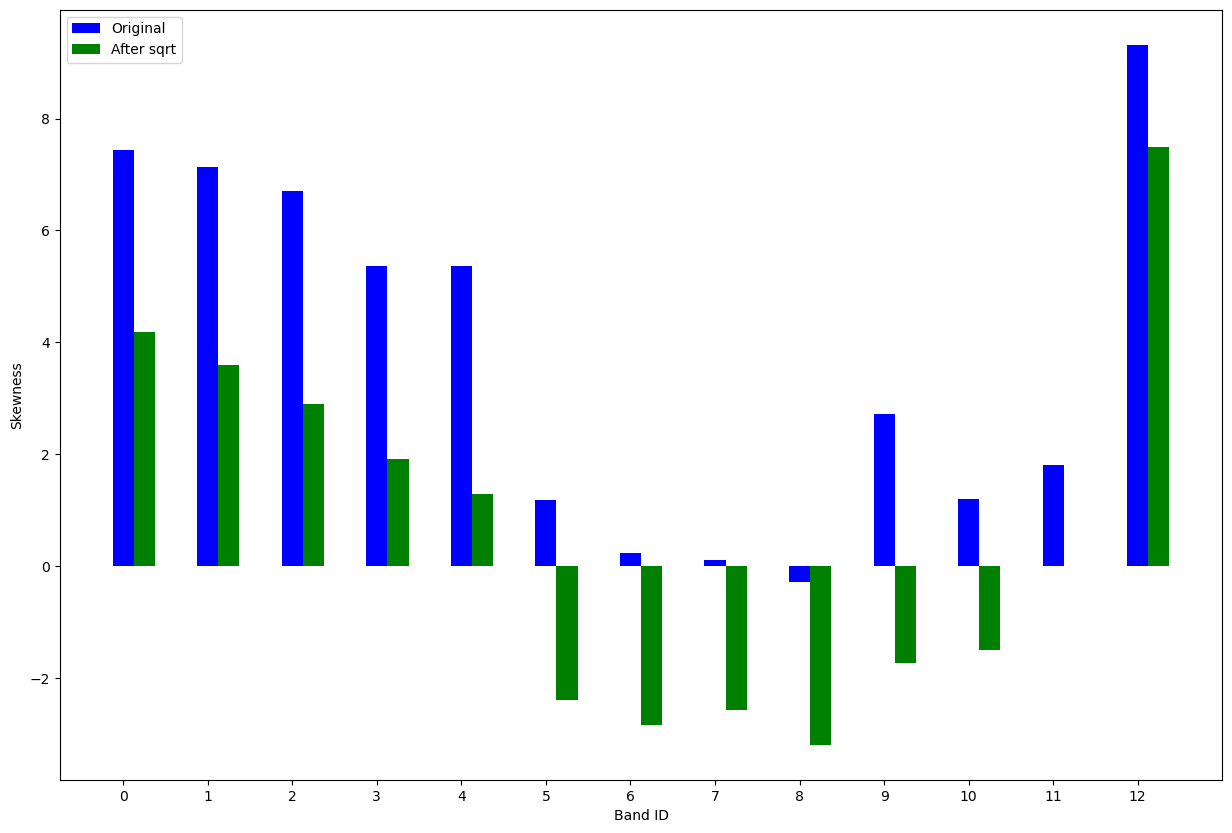

In [49]:
width = 0.25

rng = [i for i in range(0,13)]
rng2 = [i+width for i in range(0,13)]

plt.bar(rng, band_skewness, align='center', width = width, label='Original', color ='b')
plt.bar(rng2, band_skewness_after_sqrt, align='center', width = width, label='After sqrt', color ='g')
plt.gca().set_xticks(rng)
plt.legend()
plt.xlabel('Band ID')
plt.ylabel('Skewness')
plt.show()

## Data Preprocessing

In [50]:
#generate vegitation indecies for training and testing data
ndvi = (imgs[:,:,7:8,:,:] - imgs[:,:,3:4,:,:]) / (imgs[:,:,7:8,:,:] + imgs[:,:,3:4,:,:] + 1e-6)
ndwi_green = (imgs[:,:,2:3,:,:] - imgs[:,:,7:8,:,:]) / (imgs[:,:,2:3,:,:] + imgs[:,:,7:8,:,:] + 1e-6)
ndwi_blue = (imgs[:,:,1:2,:,:] - imgs[:,:,7:8,:,:]) / (imgs[:,:,1:2,:,:] + imgs[:,:,7:8,:,:] + 1e-6)

In [51]:
#apply sqrt to lower skewness
imgs = np.sqrt(imgs)